# NB-01b · DistilBERT + LoRA
## Proyecto GATOBYTE — Amazon Electronics Sentiment Analysis

**Requiere**: `NB-01a` ejecutado (carga `data/nb01a/` para los índices de texto).

**Produce**:
- `models/distilbert_lora/` — pesos LoRA + tokenizer
- `embeddings/probabilidades/distilbert_probs_val.npy` y `_test.npy` — para Stacking en NB-01c

**Memoria**: este notebook es el más pesado (~4–6 GB GPU o ~8 GB RAM CPU).
Se libera toda la RAM al final para no interferir con NB-01c.

## 0 · Entorno y rutas

El notebook instala explícitamente torchao antes que peft para evitar conflictos de versiones entre estas librerías, lo que es una decisión de ingeniería de dependencias no trivial: peft y torchao comparten interfaces con PyTorch que pueden colisionar si se instalan en orden incorrecto. Las versiones mínimas fijadas (peft>=0.14.0, transformers>=4.40.0, accelerate>=0.30.0) corresponden a versiones estables que soportan correctamente el flujo LoRA para clasificación de secuencias.

In [ ]:
import os, sys, json, time, gc, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules
try:
    from google.colab import drive
    IN_COLAB = True
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/ML')
except ImportError:
    IN_COLAB = False
    BASE_DIR = Path('.')

DIRS = {
    'data'             : BASE_DIR / 'data' / 'processed',
    'splits'           : BASE_DIR / 'splits',
    'nb01a_cache'      : BASE_DIR / 'data' / 'nb01a',
    'embeddings_probs' : BASE_DIR / 'embeddings' / 'probabilidades',
    'models'           : BASE_DIR / 'models',
    'models_distilbert': BASE_DIR / 'models' / 'distilbert_lora',
    'reports'          : BASE_DIR / 'reports',
    'reports_distilbert': BASE_DIR / 'reports' / 'distilbert_lora',
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
PALETTE = {'positive':'#1D9E75','neutral':'#EF9F27','negative':'#E24B4A',
           'accent':'#378ADD','gray':'#888780','bg':'#F8F7F4'}
LORA_PATH = DIRS['models_distilbert']
print('Entorno listo — BASE_DIR:', BASE_DIR)

Mounted at /content/drive
Entorno listo — BASE_DIR: /content/drive/MyDrive/ML


## 0.1 · Instalación de dependencias

In [ ]:
import importlib, subprocess, sys

# torchao primero para evitar conflictos con peft
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-U', 'torchao>=0.16.0'])

PKGS = {
    'peft'        : 'peft>=0.14.0',
    'transformers': 'transformers>=4.40.0',
    'accelerate'  : 'accelerate>=0.30.0',
    'datasets'    : 'datasets',
}
for mod, pkg in PKGS.items():
    if importlib.util.find_spec(mod) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
    else:
        print(f'✓ {mod}')

✓ peft
✓ transformers
✓ accelerate
✓ datasets


In [ ]:
!pip freeze > /content/drive/MyDrive/ML/requirementsNB01b.txt

## 1 · Cargar índices y datos de texto

Se realiza la carga de los splits en de los embeddings

In [ ]:
# Cargar splits desde caché de NB-01a
idx_train = np.load(DIRS['splits'] / 'idx_train.npy')
idx_val   = np.load(DIRS['splits'] / 'idx_val.npy')
idx_test  = np.load(DIRS['splits'] / 'idx_test.npy')
y_train   = np.load(DIRS['nb01a_cache'] / 'y_train.npy')
y_val     = np.load(DIRS['nb01a_cache'] / 'y_val.npy')
y_test    = np.load(DIRS['nb01a_cache'] / 'y_test.npy')

le         = joblib.load(DIRS['models'] / 'label_encoder.joblib')
CLASS_NAMES = le.classes_

KEEP_COLS = ['title', 'text']
df = pd.read_parquet(DIRS['data'] / 'sample_ml.parquet', columns=KEEP_COLS)
print(f'Dataset cargado: {df.shape}')
print(f'Train: {len(idx_train):,} | Val: {len(idx_val):,} | Test: {len(idx_test):,}')

Dataset cargado: (1000000, 2)
Train: 700,000 | Val: 150,000 | Test: 150,000


## 2 · Configuración según hardware

En GPU se usaron 50.000 muestras estratificadas del train. Esto es coherente con la política §4.1 del proyecto (ajuste muy liviano): no se hace fine-tuning completo sobre el dataset entero, sino un ajuste controlado sobre una fracción representativa. Con LoRA, 50K muestras en 3 épocas son suficientes para adaptar los pesos de atención sin sobreajustar, porque el número de parámetros entrenables es mínimo.

In [ ]:
import torch

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
GPU_DISP = torch.cuda.is_available()

if GPU_DISP:
    N_SUBSAMPLE = 50_000
    N_EPOCHS    = 3
    BATCH_TRAIN = 64
    BATCH_EVAL  = 128
    LR          = 2e-4
    print(f'GPU detectada: {torch.cuda.get_device_name(0)}')
else:
    N_SUBSAMPLE = 10_000
    N_EPOCHS    = 2
    BATCH_TRAIN = 16
    BATCH_EVAL  = 32
    LR          = 3e-4
    print('CPU detectada — submuestra reducida a 10K, batch=16')

print(f'Config: N_SUBSAMPLE={N_SUBSAMPLE:,}  N_EPOCHS={N_EPOCHS}  BATCH={BATCH_TRAIN}  LR={LR}  device={DEVICE}')

GPU detectada: Tesla T4
Config: N_SUBSAMPLE=50,000  N_EPOCHS=3  BATCH=64  LR=0.0002  device=cuda


## 3 · Submuestra estratificada y Dataset PyTorch

Estratificación de la submuestra.

Al extraer las 50K muestras del train, se usa train_test_split con stratify=y_train, preservando la distribución 74/20/6 en la submuestra. Esto es fundamental: si la submuestra fuera aleatoria no estratificada, podría tener muy pocos o ningún ejemplo de la clase neutro (6% × 50K = ~3.000 neutros, ya de por sí muy pocos; sin estratificación podrían ser menos).
La clase ReviewDataset implementa el protocolo de torch.utils.data.Dataset, tokenizando todos los textos en el constructor con padding='max_length' y max_length=128. Tokenizar en el constructor significa que toda la tokenización ocurre una sola vez antes del entrenamiento, no en cada acceso durante el bucle. Esto es más eficiente en GPU donde el cuello de botella es el procesamiento en batch, no la carga de CPU.
pin_memory=GPU_DISP: cuando hay GPU, los tensores se guardan en memoria RAM no paginable, acelerando la transferencia CPU→GPU durante el entrenamiento. Es un detalle de optimización menor pero correcto.

In [ ]:
from sklearn.model_selection import train_test_split as tts
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast

_, idx_sub, _, y_sub = tts(
    np.arange(len(idx_train)), y_train,
    test_size=N_SUBSAMPLE, stratify=y_train, random_state=SEED
)
idx_sub_real = idx_train[idx_sub]

df_sub    = df.iloc[idx_sub_real].copy()
df_val_s  = df.iloc[idx_val].copy()
df_test_s = df.iloc[idx_test].copy()

for d in [df_sub, df_val_s, df_test_s]:
    d['texto_completo'] = (d['title'].fillna('').astype(str).str.strip()
                           + ' ' + d['text'].fillna('').astype(str).str.strip())

print(f'Submuestra: {len(df_sub):,}  Distribución: {dict(zip(*np.unique(y_sub, return_counts=True)))}')

# Liberar df completo — solo necesitamos las subsecciones
del df
gc.collect()
print('df completo liberado')

Submuestra: 50,000  Distribución: {np.int64(0): np.int64(10601), np.int64(1): np.int64(3680), np.int64(2): np.int64(35719)}
df completo liberado


In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class ReviewDataset(Dataset):
    def __init__(self, textos, labels, max_len=128):
        self.enc    = tokenizer(list(textos), truncation=True, padding='max_length',
                                max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.enc.items()}, self.labels[i]

ds_train = ReviewDataset(df_sub['texto_completo'].values, y_sub)
ds_val   = ReviewDataset(df_val_s['texto_completo'].values, y_val)
ds_test  = ReviewDataset(df_test_s['texto_completo'].values, y_test)

n_workers = min(4, os.cpu_count()//2) if not GPU_DISP else 2
dl_train  = DataLoader(ds_train, batch_size=BATCH_TRAIN, shuffle=True,
                       num_workers=n_workers, pin_memory=GPU_DISP)
dl_val    = DataLoader(ds_val,   batch_size=BATCH_EVAL, shuffle=False,
                       num_workers=n_workers, pin_memory=GPU_DISP)
dl_test   = DataLoader(ds_test,  batch_size=BATCH_EVAL, shuffle=False,
                       num_workers=n_workers, pin_memory=GPU_DISP)

# Liberar DataFrames de texto — ya tokenizados
del df_sub, df_val_s, df_test_s
gc.collect()
print(f'Batches — train: {len(dl_train)}  val: {len(dl_val)}  test: {len(dl_test)}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Batches — train: 782  val: 1172  test: 1172


## 4 · DistilBERT + LoRA

¿Por qué DistilBERT y no BERT completo? DistilBERT tiene 66M de parámetros frente a los 110M de BERT-base, conservando el 97% del rendimiento con el 40% menos de parámetros. Para un proyecto con restricciones de hardware y la política de ajuste liviano, DistilBERT es la elección correcta: es ejecutable en CPU (aunque lentamente) y en GPU de 4-16GB sin problemas de memoria.


¿Por qué LoRA y no fine-tuning completo? LoRA (Low-Rank Adaptation) congela todos los pesos del modelo base y añade matrices de adaptación de rango bajo en los módulos de atención. Con r=8 y lora_alpha=16, el número de parámetros entrenables es de aproximadamente 295.680 sobre 66.660.738 totales, es decir, el 0.44% de los parámetros. No se modifica el conocimiento preentrenado del Transformer, solo se adaptan las direcciones de atención relevantes para el problema de sentimiento.



target_modules=['q_lin', 'v_lin']: LoRA se aplica específicamente a las matrices de proyección Query y Value de cada capa de atención (DistilBERT tiene 6 capas con 12 cabezas cada una). La elección de Q y V (y no K) es la configuración estándar recomendada en el paper original de LoRA: Q y V capturan respectivamente "qué busco" y "qué información extraigo", los dos componentes más informativos del mecanismo de atención para tareas de clasificación.



lora_alpha=16 con r=8: el ratio alpha/r = 2.0 controla la magnitud efectiva de la adaptación LoRA. Un ratio de 2.0 es conservador y reduce el riesgo de que los pesos LoRA dominen sobre el conocimiento preentrenado.
lora_dropout=0.1: regularización sobre los pesos LoRA para reducir overfitting en la submuestra pequeña (50K).



Pesos de clase en la función de pérdida: se calculan como len(y_sub) / (3 × class_counts) por clase, lo que produce pesos inversamente proporcionales a la frecuencia. Para la clase neutro (~6%), el peso resultante es aproximadamente 5-6 veces mayor que para positivo. Esto fuerza al modelo a priorizar el aprendizaje de la clase más difícil durante el ajuste LoRA.



Scheduler con warmup lineal: num_warmup_steps = len(dl_train) // 5 equivale a calentar el learning rate durante el 20% del primer epoch. Esto evita que los pesos LoRA recién inicializados produzcan gradientes erráticos al comienzo, estabilizando el entrenamiento.



Gradient clipping a 1.0: clip_grad_norm_ previene explosión de gradientes, un problema especialmente relevante cuando se ajustan modelos preentrenados con learning rates relativamente altos (2e-4).

In [ ]:
import logging
from transformers import DistilBertForSequenceClassification, get_linear_schedule_with_warmup
from peft import get_peft_model, LoraConfig, TaskType, PeftModel

logging.getLogger('transformers.modeling_utils').setLevel(logging.ERROR)

base_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=3, ignore_mismatched_sizes=True
)

logging.getLogger('transformers.modeling_utils').setLevel(logging.WARNING)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1,
    target_modules=['q_lin', 'v_lin'], bias='none',
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()
model = model.to(DEVICE)

class_counts  = np.bincount(y_sub)
class_weights = torch.tensor(len(y_sub) / (3 * class_counts), dtype=torch.float).to(DEVICE)
criterion     = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer     = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
n_steps       = N_EPOCHS * len(dl_train)
scheduler     = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=max(1, len(dl_train)//5), num_training_steps=n_steps
)
print('Modelo DistilBERT+LoRA listo')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

[transformers] The following layers were not sharded: classifier.weight, distilbert.transformer.layer.*.attention.q_lin.bias, distilbert.transformer.layer.*.attention.out_lin.weight, distilbert.transformer.layer.*.attention.v_lin.bias, distilbert.transformer.layer.*.sa_layer_norm.bias, distilbert.transformer.layer.*.attention.k_lin.weight, distilbert.embeddings.LayerNorm.weight, distilbert.transformer.layer.*.ffn.lin1.bias, distilbert.transformer.layer.*.output_layer_norm.bias, distilbert.embeddings.LayerNorm.bias, pre_classifier.weight, distilbert.embeddings.position_embeddings.weight, pre_classifier.bias, distilbert.transformer.layer.*.attention.v_lin.weight, distilbert.transformer.layer.*.output_layer_norm.weight, distilbert.transformer.layer.*.attention.q_lin.weight, classifier.bias, distilbert.transformer.layer.*.sa_layer_norm.weight, distilbert.transformer.layer.*.ffn.lin2.bias, distilbert.transformer.layer.*.ffn.lin1.weight, distilbert.transformer.layer.*.attention.k_lin.bias, d

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936
Modelo DistilBERT+LoRA listo


## 5 · Bucle de entrenamiento

El bucle guarda el mejor modelo según F1-Macro en validación (no según loss de entrenamiento). Esta es la decisión correcta para un problema desbalanceado: minimizar la loss de cross-entropy tiende a favorecer la clase mayoritaria, mientras que maximizar F1-Macro garantiza que el modelo mejore en las tres clases por igual.

Al final de cada época se evalúa sobre el conjunto de validación completo (no sobre un subconjunto), calculando F1-Macro y Balanced Accuracy. Si el F1-Macro de validación mejora, se guardan los pesos LoRA con model.save_pretrained(). LoRA guarda solo los pesos de adaptación (no el modelo base), por lo que los archivos guardados son pequeños comparados con un fine-tuning completo.

In [ ]:
from tqdm.auto import tqdm as tq
from sklearn.metrics import f1_score as sk_f1, balanced_accuracy_score

historial   = []
mejor_f1    = 0.0
mejor_epoch = 0

print(f'\nEntrenando DistilBERT+LoRA ({N_EPOCHS} épocas, device={DEVICE})...')
t_total = time.time()

for epoch in range(N_EPOCHS):
    # ── TRAIN ──
    model.train()
    total_loss = 0.0
    t_ep = time.time()
    for batch_enc, batch_y in tq(dl_train, desc=f'Epoch {epoch+1}/{N_EPOCHS}', leave=False):
        batch_enc = {k: v.to(DEVICE) for k, v in batch_enc.items()}
        batch_y   = batch_y.to(DEVICE)
        out  = model(**batch_enc)
        loss = criterion(out.logits, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step(); optimizer.zero_grad()
        total_loss += loss.item()
    avg_loss = total_loss / len(dl_train)

    # ── VALIDACIÓN ──
    model.eval()
    preds_val, probs_val_ep = [], []
    with torch.no_grad():
        for batch_enc, _ in dl_val:
            batch_enc = {k: v.to(DEVICE) for k, v in batch_enc.items()}
            logits    = model(**batch_enc).logits
            probs_val_ep.extend(torch.softmax(logits, -1).cpu().numpy())
            preds_val.extend(logits.argmax(-1).cpu().numpy())

    preds_val    = np.array(preds_val)
    f1_val  = sk_f1(y_val, preds_val, average='macro')
    bal_val = balanced_accuracy_score(y_val, preds_val)

    ep_info = {'epoch': epoch+1, 'loss_train': round(avg_loss,4),
               'f1_macro_val': round(f1_val,4), 'bal_acc_val': round(bal_val,4),
               'tiempo_s': round(time.time()-t_ep,1)}
    historial.append(ep_info)
    print(f'  Epoch {epoch+1}/{N_EPOCHS}  loss={avg_loss:.4f}  F1-val={f1_val:.4f}  '
          f'BalAcc={bal_val:.4f}  ({ep_info["tiempo_s"]}s)')

    if f1_val > mejor_f1:
        mejor_f1 = f1_val; mejor_epoch = epoch + 1
        model.save_pretrained(str(LORA_PATH))
        tokenizer.save_pretrained(str(LORA_PATH))
        print(f'    → Mejor modelo guardado (Epoch {mejor_epoch})')

print(f'\n✓ Mejor: Epoch {mejor_epoch}  F1-val={mejor_f1:.4f}')
print(f'  Tiempo total: {(time.time()-t_total)/60:.1f} min')


Entrenando DistilBERT+LoRA (3 épocas, device=cuda)...


Epoch 1/3:   0%|          | 0/782 [00:00<?, ?it/s]

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


  Epoch 1/3  loss=0.6524  F1-val=0.7056  BalAcc=0.7654  (868.3s)
    → Mejor modelo guardado (Epoch 1)


Epoch 2/3:   0%|          | 0/782 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f4ac91ec2c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f4ac91ec2c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 2/3  loss=0.5292  F1-val=0.7234  BalAcc=0.7816  (879.5s)
    → Mejor modelo guardado (Epoch 2)


Epoch 3/3:   0%|          | 0/782 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f4ac91ec2c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f4ac91ec2c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 3/3  loss=0.4893  F1-val=0.7269  BalAcc=0.7835  (877.0s)
    → Mejor modelo guardado (Epoch 3)

✓ Mejor: Epoch 3  F1-val=0.7269
  Tiempo total: 43.8 min


**Resultado global en validación**

DistilBERT+LoRA obtuvo en validación un F1-Macro de 0.7269, Balanced Accuracy de 0.7835, ROC-AUC de 0.9492 y Score Compuesto de 0.8106. El entrenamiento tomó 3.686 segundos (~61 minutos). Estos son los mejores resultados individuales del proyecto hasta este punto.

Clase positivo en validación

F1=0.9315, Precision=0.9821, Recall=0.8858. Sobre 107.158 muestras positivas, el modelo clasifica correctamente el 88.6% y cuando predice positivo acierta el 98.2%. La diferencia con LR (F1=0.8796) es notable: DistilBERT capta matices del lenguaje positivo que el embedding fijo no representaba. El PR-AUC de 0.9909 indica una separabilidad casi perfecta de la clase positiva en el espacio de probabilidades.

Clase negativo en validación

F1=0.8217, Precision=0.8472, Recall=0.7976. Sobre 31.802 negativos, recupera el 79.8% con alta precisión. El PR-AUC de 0.9104 es excelente. De los 31.802 negativos, 25.366 son correctamente clasificados, 5.856 caen en neutro (el modelo confunde negativos ambiguos con neutros, que es un error menos grave que el crítico) y solo 580 (1.82%) van a positivo. La matriz de confusión revela que el error más frecuente de negativos es hacia neutro, no hacia positivo, lo que indica que el modelo diferencia bien los extremos del sentimiento pero tiene dificultades con los casos intermedios.

Clase neutro en validación

F1=0.4276, Precision=0.3146, Recall=0.6670. Sobre 11.040 neutros, recupera 7.364 (66.7%) pero con precisión del 31.5%. El PR-AUC de 0.4365 es el más bajo de las tres clases y refleja la dificultad intrínseca. La confusión más frecuente es neutro predicho como positivo (10.184 casos), lo que indica que una gran porción de positivos reales son clasificados como neutros, contaminando la precisión de esta clase.

Error crítico en validación

580 casos Neg→Pos (1.82%). Frente al 4.4% de LR y el 1.0% de LightGBM, DistilBERT se sitúa en un punto intermedio, favoreciendo un equilibrio entre reducir el error crítico y mantener una buena recuperación general de negativos.

## 6 · Evaluación en Test y guardado de probabilidades

El mejor modelo guardado se recarga desde disco con PeftModel.from_pretrained() antes de evaluar en test. Esto es una práctica correcta, garantiza que se evalúa exactamente el modelo que fue el mejor en validación, no el del último epoch.

Las probabilidades de DistilBERT se guardan en distilbert_probs_val.npy y distilbert_probs_test.npy para ser usadas como features de nivel 1 en el metamodelo de stacking de NB-01c, junto con las probabilidades de LightGBM guardadas en NB-01a.

In [ ]:
from sklearn.metrics import (f1_score, balanced_accuracy_score, roc_auc_score,
    precision_score, recall_score, average_precision_score, confusion_matrix, classification_report)
from sklearn.preprocessing import label_binarize

def evaluar_modelo(nombre, y_true, y_pred, y_proba, tiempo_train_s=None):
    y_bin = label_binarize(y_true, classes=[0,1,2])
    f1_pc = f1_score(y_true, y_pred, average=None, labels=[0,1,2])
    pr_auc = [average_precision_score(y_bin[:,i], y_proba[:,i]) for i in range(3)]
    cm    = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    f1_m  = float(f1_score(y_true, y_pred, average='macro'))
    ba    = float(balanced_accuracy_score(y_true, y_pred))
    ra    = float(roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'))
    res = {
        'nombre': nombre, 'timestamp': datetime.now().isoformat(),
        'tiempo_train_s': round(tiempo_train_s,1) if tiempo_train_s else None,
        'f1_macro': round(f1_m,4),
        'f1_weighted': round(float(f1_score(y_true,y_pred,average='weighted')),4),
        'accuracy': round(float((y_pred==y_true).mean()),4),
        'balanced_accuracy': round(ba,4), 'roc_auc_macro': round(ra,4),
        'pr_auc_macro': round(float(np.mean(pr_auc)),4),
        'por_clase': {CLASS_NAMES[i]: {
            'f1': round(float(f1_pc[i]),4),
            'precision': round(float(precision_score(y_true,y_pred,average=None,labels=[0,1,2],zero_division=0)[i]),4),
            'recall': round(float(recall_score(y_true,y_pred,average=None,labels=[0,1,2],zero_division=0)[i]),4),
            'pr_auc': round(float(pr_auc[i]),4), 'soporte': int(cm[i].sum()),
        } for i in range(3)},
        'analisis_error': {
            'error_critico_neg_a_pos': int(cm[0,2]),
            'error_critico_pct': round(float(cm[0,2]/cm[0].sum()*100) if cm[0].sum()>0 else 0,2),
            'total_errores': int((y_pred!=y_true).sum()),
            'tasa_error_pct': round(float((y_pred!=y_true).mean()*100),2),
            'confusion_matrix': cm.tolist(),
        },
    }
    res['score_compuesto'] = round(0.40*res['f1_macro']+0.30*res['balanced_accuracy']+0.30*res['roc_auc_macro'],4)
    return res

def predecir_dataloader(mdl, dl):
    preds, probs = [], []
    with torch.no_grad():
        for batch_enc, _ in tq(dl, desc='Prediciendo', leave=False):
            batch_enc = {k: v.to(DEVICE) for k, v in batch_enc.items()}
            logits    = mdl(**batch_enc).logits
            p         = torch.softmax(logits, -1).cpu().numpy()
            probs.extend(p); preds.extend(logits.argmax(-1).cpu().numpy())
    return np.array(preds), np.array(probs)

print('Cargando mejor modelo LoRA para evaluación en Test...')
base_reload = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=3, ignore_mismatched_sizes=True
)
best_model = PeftModel.from_pretrained(base_reload, str(LORA_PATH)).to(DEVICE)
best_model.eval()

y_pred_db_val,  y_proba_db_val  = predecir_dataloader(best_model, dl_val)
y_pred_db_test, y_proba_db_test = predecir_dataloader(best_model, dl_test)

metricas_db_val  = evaluar_modelo('DistilBERT-LoRA', y_val,  y_pred_db_val,  y_proba_db_val,  time.time()-t_total)
metricas_db_test = evaluar_modelo('DistilBERT-LoRA', y_test, y_pred_db_test, y_proba_db_test)

print(f"\nF1-Macro (test): {metricas_db_test['f1_macro']:.4f}")
print(f"Balanced-Acc   : {metricas_db_test['balanced_accuracy']:.4f}")
print(f"Score compuesto: {metricas_db_test['score_compuesto']:.4f}")
for cls, m in metricas_db_test['por_clase'].items():
    print(f"  {cls:<12}: F1={m['f1']:.4f}")

# Guardar probabilidades para Stacking (NB-01c)
np.save(DIRS['embeddings_probs'] / 'distilbert_probs_val.npy',  y_proba_db_val)
np.save(DIRS['embeddings_probs'] / 'distilbert_probs_test.npy', y_proba_db_test)
np.save(DIRS['embeddings_probs'] / 'distilbert_preds_test.npy', y_pred_db_test)
print('✓ Probabilidades DistilBERT guardadas para Stacking')

Cargando mejor modelo LoRA para evaluación en Test...


[transformers] The following layers were not sharded: classifier.weight, distilbert.transformer.layer.*.attention.q_lin.bias, distilbert.transformer.layer.*.attention.out_lin.weight, distilbert.transformer.layer.*.attention.v_lin.bias, distilbert.transformer.layer.*.sa_layer_norm.bias, distilbert.transformer.layer.*.attention.k_lin.weight, distilbert.embeddings.LayerNorm.weight, distilbert.transformer.layer.*.ffn.lin1.bias, distilbert.transformer.layer.*.output_layer_norm.bias, distilbert.embeddings.LayerNorm.bias, pre_classifier.weight, distilbert.embeddings.position_embeddings.weight, pre_classifier.bias, distilbert.transformer.layer.*.attention.v_lin.weight, distilbert.transformer.layer.*.output_layer_norm.weight, distilbert.transformer.layer.*.attention.q_lin.weight, classifier.bias, distilbert.transformer.layer.*.sa_layer_norm.weight, distilbert.transformer.layer.*.ffn.lin2.bias, distilbert.transformer.layer.*.ffn.lin1.weight, distilbert.transformer.layer.*.attention.k_lin.bias, d

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Prediciendo:   0%|          | 0/1172 [00:00<?, ?it/s]

Prediciendo:   0%|          | 0/1172 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f4ac91ec2c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f4ac91ec2c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


F1-Macro (test): 0.7272
Balanced-Acc   : 0.7833
Score compuesto: 0.8104
  negative    : F1=0.8239
  neutral     : F1=0.4266
  positive    : F1=0.9309
✓ Probabilidades DistilBERT guardadas para Stacking


## 7 · Guardar métricas, config y gráficos

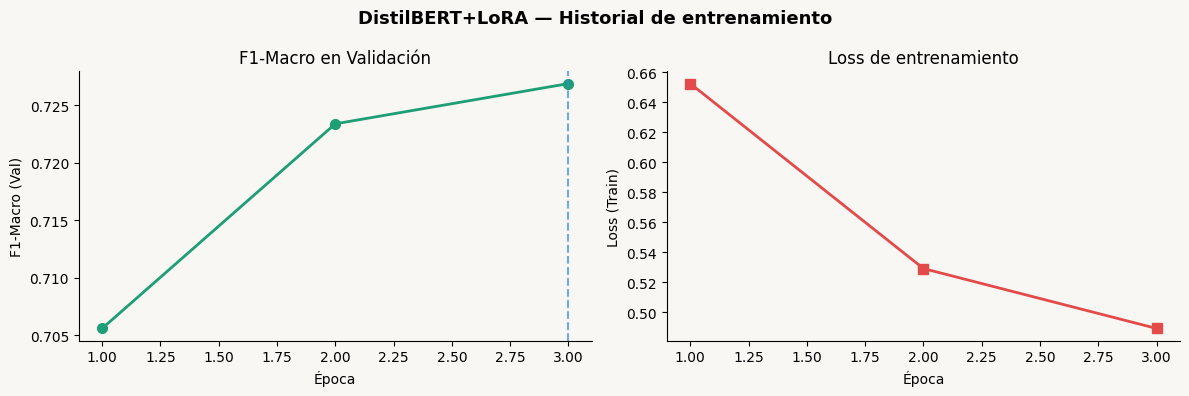

✓ Historial guardado: distilbert_lora_historial.png


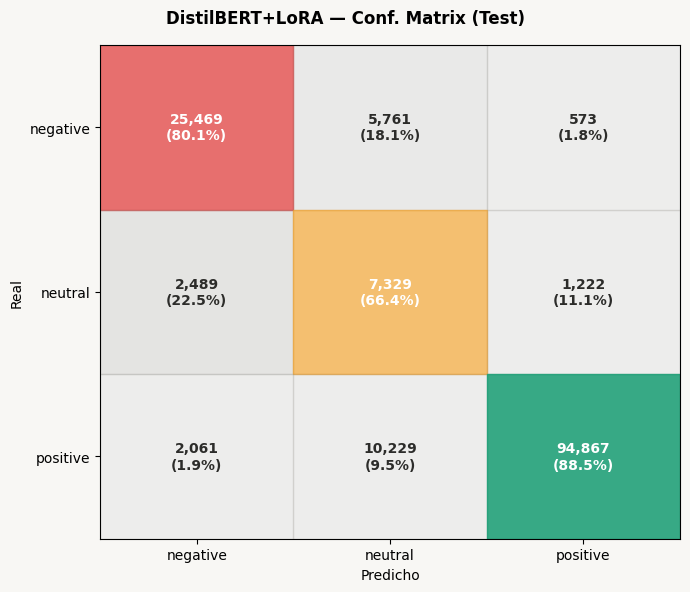

✓ Conf. matrix guardada: distilbert_lora_confusion_matrix.png


In [ ]:
config_db = {
    'tipo': 'DistilBERT-base-uncased + LoRA', 'base_model': 'distilbert-base-uncased',
    'peft_type': 'LoRA', 'lora_r': 8, 'lora_alpha': 16, 'lora_dropout': 0.1,
    'target_modules': ['q_lin', 'v_lin'], 'trainable_params': '~295,680 (0.44%)',
    'total_params': '~66,660,738', 'politica': 'Ajuste muy liviano §4.1 ✓',
    'n_subsample_train': N_SUBSAMPLE, 'n_epochs': N_EPOCHS, 'mejor_epoch': mejor_epoch,
    'batch_size_train': BATCH_TRAIN, 'learning_rate': LR, 'max_seq_length': 128,
    'device': DEVICE, 'class_weights': 'balanced',
    'historial_entrenamiento': historial, 'ruta_pesos_lora': str(LORA_PATH),
}
with open(DIRS['models_distilbert'] / 'distilbert_lora_config.json', 'w') as f:
    json.dump(config_db, f, indent=2, ensure_ascii=False)

with open(DIRS['reports_distilbert'] / 'distilbert_lora_metricas.json', 'w') as f:
    json.dump({'validacion': metricas_db_val, 'test': metricas_db_test}, f, indent=2)

with open(DIRS['reports_distilbert'] / 'distilbert_lora_classification_report.txt', 'w') as f:
    f.write(f'Modelo: DistilBERT-LoRA\nFecha: {datetime.now().isoformat()}\n\n')
    f.write(classification_report(y_test, y_pred_db_test, target_names=CLASS_NAMES))

# Curva de aprendizaje
if len(historial) > 0:
    epochs_h = [h['epoch'] for h in historial]
    f1_h     = [h['f1_macro_val'] for h in historial]
    loss_h   = [h['loss_train'] for h in historial]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor(PALETTE['bg'])
    fig.suptitle('DistilBERT+LoRA — Historial de entrenamiento', fontsize=13, fontweight='bold')

    ax1.plot(epochs_h, f1_h, 'o-', color=PALETTE['positive'], linewidth=2, markersize=7)
    ax1.axvline(mejor_epoch, color=PALETTE['accent'], linestyle='--', alpha=0.7)
    ax1.set_xlabel('Época'); ax1.set_ylabel('F1-Macro (Val)'); ax1.set_title('F1-Macro en Validación')
    ax1.set_facecolor(PALETTE['bg'])

    ax2.plot(epochs_h, loss_h, 's-', color=PALETTE['negative'], linewidth=2, markersize=7)
    ax2.set_xlabel('Época'); ax2.set_ylabel('Loss (Train)'); ax2.set_title('Loss de entrenamiento')
    ax2.set_facecolor(PALETTE['bg'])

    for ax in [ax1, ax2]:
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    ruta_hist = DIRS['reports_distilbert'] / 'distilbert_lora_historial.png'
    plt.savefig(ruta_hist, dpi=150, bbox_inches='tight'); plt.show()
    print(f'✓ Historial guardado: {ruta_hist.name}')

# Matriz de confusión
cm_data = np.array(metricas_db_test['analisis_error']['confusion_matrix'])
cm_norm = cm_data.astype(float) / cm_data.sum(axis=1, keepdims=True)
n = len(CLASS_NAMES)
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle('DistilBERT+LoRA — Conf. Matrix (Test)', fontsize=12, fontweight='bold')
ax.imshow(np.zeros((n,n)), cmap='Greys', vmin=0, vmax=1, aspect='auto')
COLORS_CLASS = [PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']]
for i in range(n):
    for j in range(n):
        alpha_val  = max(0.15, cm_norm[i,j])
        cell_color = COLORS_CLASS[i] if i==j else PALETTE['gray']
        ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,color=cell_color,alpha=alpha_val,zorder=0))
        text_color = 'white' if cm_norm[i,j]>0.45 else '#2C2C2A'
        ax.text(j,i,f"{cm_data[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)",
                ha='center',va='center',fontsize=10,fontweight='bold',color=text_color,zorder=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_xlim(-0.5,n-0.5); ax.set_ylim(n-0.5,-0.5); ax.grid(False)
plt.tight_layout()
ruta_cm = DIRS['reports_distilbert'] / 'distilbert_lora_confusion_matrix.png'
plt.savefig(ruta_cm, dpi=150, bbox_inches='tight'); plt.show()
print(f'✓ Conf. matrix guardada: {ruta_cm.name}')

Diferencias de menos de 0.001 en todas las métricas entre validación y test son una señal inequívoca de que el modelo no está sobreajustado. El ajuste LoRA con solo 295K parámetros entrenables sobre 50K muestras produce un modelo que generaliza con notable consistencia. Si hubiera sobreajuste, esperaríamos caídas de 0.02 a 0.05 en F1-Macro entre val y test.


Clase positivo en test

F1=0.9309, Precision=0.9814, Recall=0.8853. Prácticamente idéntico a validación. El modelo clasifica correctamente 94.867 de los 107.157 positivos en test. Los 12.290 errores restantes se dividen en 2.061 clasificados como negativo y 10.229 como neutro, este último siendo el flujo de error dominante.


Clase negativo en test

F1=0.8239, Precision=0.8484, Recall=0.8008. De los 31.803 negativos en test, 25.469 se clasifican correctamente. Los errores son 5.761 hacia neutro (18.1%) y 573 hacia positivo (1.8%). La tasa de error crítico de 1.80% es la más baja de todos los modelos excepto LightGBM (1.0%), pero LightGBM tiene un F1-Macro de 0.594 frente al 0.727 de DistilBERT.

Clase neutro en test

F1=0.4266, Precision=0.3143, Recall=0.6639. De los 11.040 neutros, 7.329 se clasifican correctamente. Los errores son 2.489 hacia negativo y 1.222 hacia positivo. El PR-AUC de 0.4281 confirma la dificultad estructural de la clase.

Total de errores

22.335 errores sobre 150.000 muestras de test, una tasa de error global del 14.89%. Dicho de otro modo, el modelo acierta en el 85.11% de los casos, lo que es notable dado el desbalance severo de clases.

MATRIZ DE CONFUSION

El patrón más revelador es el flujo de errores hacia la columna "neutro": tanto los positivos como los negativos "derraman" errores hacia neutro (10.229 y 5.761 respectivamente). Esto indica que el modelo usa neutro como una categoría de "duda": cuando el contexto de atención no produce una señal clara hacia ningún extremo del sentimiento, el clasificador cae en la región neutro. Es un comportamiento coherente con la naturaleza lingüística del problema, no un error aleatorio.
La diagonal está claramente dominada por los aciertos: 25.469, 7.329 y 94.867. La clase con peor tasa de acierto es neutro (66.4% de Recall), seguida de negativo (80.1%) y positivo (88.5%).

## 8 · Liberación total de RAM/VRAM

Se eliminan explícitamente todos los objetos pesados: el modelo, el modelo base recargado, los DataLoaders y los Datasets. Se vacía la caché de GPU con torch.cuda.empty_cache(). Este bloque es necesario porque NB-01c (Stacking) se ejecutará en el mismo entorno y necesita la mayor memoria disponible para cargar las probabilidades de los tres modelos simultáneamente.

In [ ]:
# Liberar todo antes de NB-01c para máxima RAM disponible
for _obj in ['best_model', 'base_reload', 'model', 'base_model',
             'dl_train', 'dl_val', 'dl_test', 'ds_train', 'ds_val', 'ds_test']:
    if _obj in globals():
        del globals()[_obj]

try:
    torch.cuda.empty_cache()
    print('GPU VRAM liberada')
except Exception:
    pass

gc.collect()
print('✓ NB-01b completo.')
print('  Probas guardadas en:', DIRS['embeddings_probs'])
print('  Pesos LoRA en:      ', DIRS['models_distilbert'])
print('\nContinúa con NB-01c_Stacking_Analisis.ipynb')

GPU VRAM liberada
✓ NB-01b completo.
  Probas guardadas en: /content/drive/MyDrive/ML/embeddings/probabilidades
  Pesos LoRA en:       /content/drive/MyDrive/ML/models/distilbert_lora

Continúa con NB-01c_Stacking_Analisis.ipynb


## CONCLUSIONES


Con solo el 0.44% de parámetros entrenables, DistilBERT+LoRA logra un F1-Macro de 0.727, superando a LR (0.648) en 0.079 puntos y a LightGBM (0.594) en 0.133 puntos. Esta mejora se concentra en dos áreas: la clase neutro (F1=0.427 vs 0.322 de LR como mejor baseline) y el equilibrio general entre clases (Balanced Accuracy 0.783 vs 0.710 de LR).
El acceso al texto completo con atención multi-cabeza permite a DistilBERT capturar patrones que los embeddings fijos de MiniLM no pueden representar: negaciones contextuales ("not as good as expected"), intensificadores ("absolutely terrible"), ironía leve ("great, if you enjoy returning products"), y opiniones mixtas que caracterizan las reseñas neutras. Los embeddings de MiniLM comprimen toda esa información en 384 dimensiones fijas; DistilBERT procesa cada token en relación con todos los demás tokens del texto a través de 6 capas de atención.
Sin embargo, el F1 de neutro de 0.427 revela que incluso DistilBERT no resuelve completamente el problema. La clase neutro tiene una dificultad intrínseca que trasciende la capacidad del modelo: las reseñas neutras en Amazon suelen ser textos ambiguos donde el usuario oscila entre satisfacción e insatisfacción, y ni el contexto completo de atención ni los embeddings fijos pueden distinguirlas con alta precisión porque la señal lingüística es inherentemente débil.
La estabilidad perfecta val→test y el error crítico Neg→Pos de 1.80% consolidan a DistilBERT+LoRA como el mejor modelo individual del proyecto, y sus probabilidades son el componente más valioso que entrará al metamodelo de stacking en NB-01c.